# traning_result_analysis

Faithful recreation (from the recovered PDF) of the **training** analysis (§4.1): convergence,
per-class difficulty, precision/recall trade-offs, compute footprint and seed robustness.

**Inputs:** `training_analytics_{swin,beit,internImage,flash,hrnet}.xlsx` (one row per validation
point of the *completed* training run of each seed). Regenerated from the Azure training logs with
`scripts/parse_training_logs.py`. The full narrative analysis is in `source_pdf/traning_result_analysis_flowity.pdf`.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itables import init_notebook_mode
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
init_notebook_mode(True)

In [2]:
model_files = {
    "Swin-T": "./training_analytics_swin.xlsx",
    "BeiT2-T": "./training_analytics_beit.xlsx",
    "InterImage-T": "./training_analytics_internImage.xlsx",
    "FlashInterImage-T": "./training_analytics_flash.xlsx",
    "HRNet-T": "./training_analytics_hrnet.xlsx"
}

In [3]:
# Combine all model xlsx files into a master table
all_dfs = []
for model_name, file_path in model_files.items():
    df_temp = pd.read_excel(file_path, engine='openpyxl')
    df_temp["backbone"] = model_name
    all_dfs.append(df_temp)

df_master = pd.concat(all_dfs, ignore_index=True)
cols = ['backbone', 'seed', 'iter']
remaining_cols = [c for c in df_master.columns if c not in cols]
df_master = df_master[cols + remaining_cols]

df_master.to_excel("master_table.xlsx", index=False, engine="openpyxl")
print(f"Successfully processed master table with {df_master.shape[0]} total metric rows.")

Successfully processed master table with 789 total metric rows.


In [4]:
# Peak mIoU row per (model, seed)
idx_max_miou = df_master.groupby(['backbone', 'seed'])['mIoU'].idxmax()
df_best_per_seed = df_master.loc[idx_max_miou].copy().reset_index(drop=True)
print(f"Extracted {len(df_best_per_seed)} peak rows (1 per seed per architecture).")
display(df_best_per_seed)

Extracted 25 peak rows (1 per seed per architecture).


Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


In [5]:
idx_best_seed = df_best_per_seed.groupby('backbone')['mIoU'].idxmax()
df_best_seeds = df_best_per_seed.loc[idx_best_seed, ['backbone', 'seed', 'mIoU']].sort_values(by='mIoU', ascending=False)
print(" Best absolute seed per model (peak mIoU):")
for _, row in df_best_seeds.iterrows():
    print(f" - {row['backbone']:<18} -> best run: {row['seed']} (mIoU: {row['mIoU']:.2f}%)")
print("\n" + "="*70 + "\n")

global_cols = ['iter', 'mIoU', 'aAcc', 'loss', 'train_time']
class_iou_cols = [c for c in df_best_per_seed.columns if c.startswith('IoU.')]
target_metrics = global_cols + class_iou_cols
df_stats = df_best_per_seed.groupby('backbone')[target_metrics].agg(['mean', 'std'])
df_stats

 Best absolute seed per model (peak mIoU):
 - BeiT2-T            -> best run: seed_91 (mIoU: 43.26%)
 - Swin-T             -> best run: seed_91 (mIoU: 42.90%)
 - FlashInterImage-T  -> best run: seed_91 (mIoU: 41.59%)
 - InterImage-T       -> best run: seed_777 (mIoU: 40.82%)
 - HRNet-T            -> best run: seed_1337 (mIoU: 40.10%)




Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


In [6]:
# Publication master table (mean +/- std, sorted by mean mIoU)
df_stats_sorted = df_stats.sort_values(by=('mIoU', 'mean'), ascending=False)
df_publication = pd.DataFrame(index=df_stats_sorted.index)
for metric in target_metrics:
    df_publication[metric] = (
        df_stats_sorted[metric]['mean'].map('{:.2f}'.format) + " \u00b1 " +
        df_stats_sorted[metric]['std'].map('{:.2f}'.format)
    )
df_publication = df_publication.reset_index().rename(columns={'backbone': 'Arquitectura'})
print(" Academic Master Table (Sorted Numerically by Mean mIoU):")
display(df_publication)

 Academic Master Table (Sorted Numerically by Mean mIoU):


Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


 Mean Functional Loss Breakdown at Peak Performance:


Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


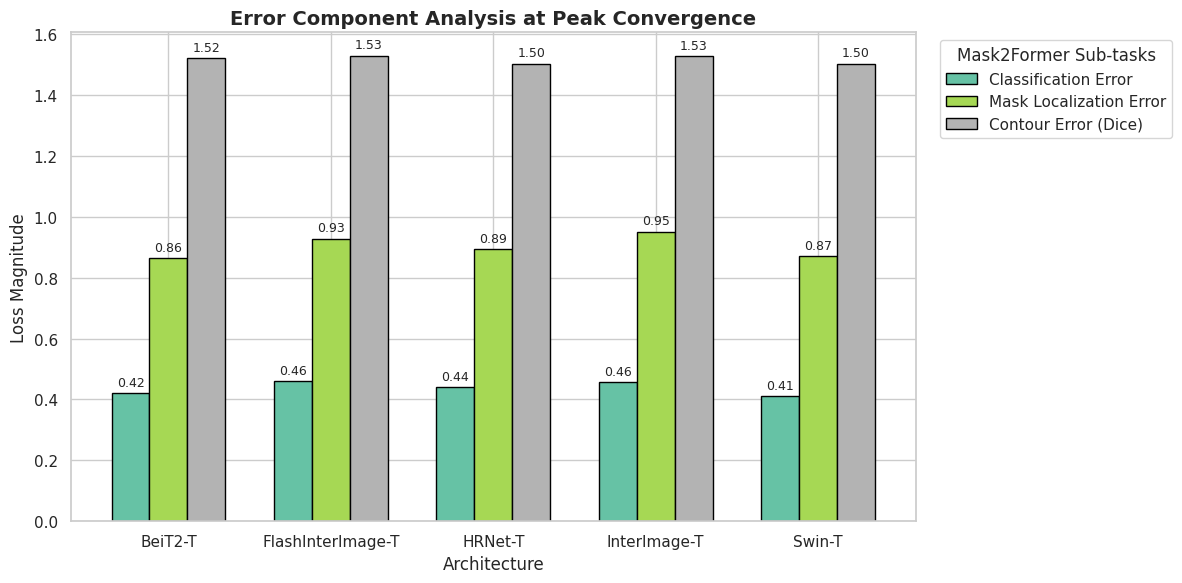

In [7]:
# Loss decomposition at peak
loss_components = ['loss_cls', 'loss_mask', 'loss_dice']
df_loss_decomp = df_best_per_seed.groupby('backbone')[loss_components].mean().round(3)
df_loss_decomp.columns = ['Classification Error', 'Mask Localization Error', 'Contour Error (Dice)']
print(" Mean Functional Loss Breakdown at Peak Performance:")
display(df_loss_decomp)

ax = df_loss_decomp.plot(kind='bar', colormap='Set2', edgecolor='black', width=0.7)
plt.title("Error Component Analysis at Peak Convergence", fontsize=14, fontweight='bold')
plt.xlabel("Architecture", fontsize=12); plt.ylabel("Loss Magnitude", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Mask2Former Sub-tasks", bbox_to_anchor=(1.02, 1), loc='upper left')
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
plt.tight_layout(); plt.show()

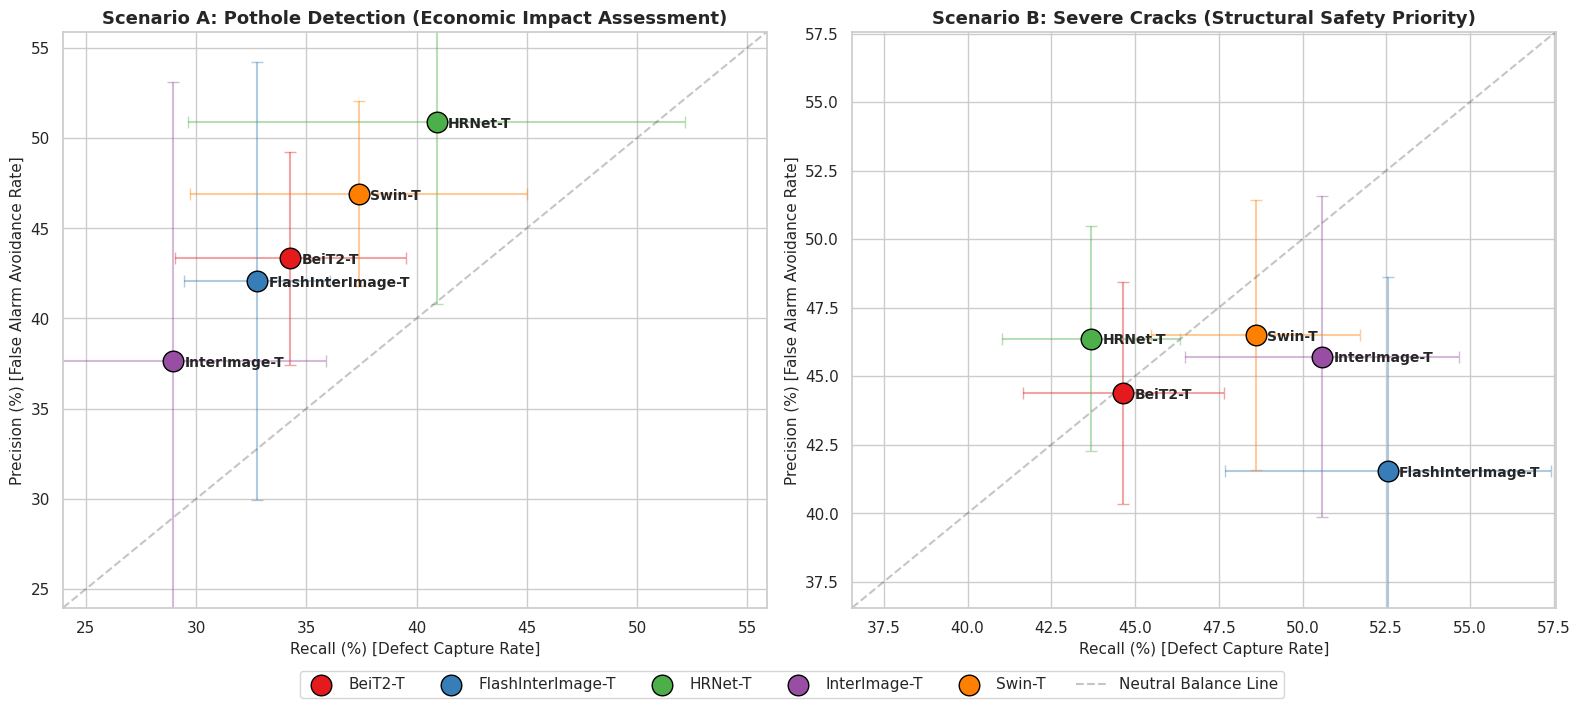

In [8]:
# Precision-Recall dilemma per class
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
archs = df_best_per_seed['backbone'].unique()
color_map = dict(zip(archs, sns.color_palette("Set1", len(archs))))

def plot_dilemma(ax, target_class, title):
    df_agg = df_best_per_seed.groupby('backbone').agg(
        P_Mean=(f'Precision.{target_class}', 'mean'), P_Std=(f'Precision.{target_class}', 'std'),
        R_Mean=(f'Recall.{target_class}', 'mean'), R_Std=(f'Recall.{target_class}', 'std')
    ).reset_index()
    for _, row in df_agg.iterrows():
        ax.scatter(row['R_Mean'], row['P_Mean'], s=220, color=color_map[row['backbone']],
                   edgecolors='black', zorder=3, label=row['backbone'])
        ax.errorbar(row['R_Mean'], row['P_Mean'], xerr=row['R_Std'], yerr=row['P_Std'],
                    fmt='none', ecolor=color_map[row['backbone']], alpha=0.4, capsize=4, zorder=2)
        ax.annotate(row['backbone'], (row['R_Mean'], row['P_Mean']), xytext=(8, -4),
                    textcoords='offset points', fontsize=10, weight='semibold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Recall (%) [Defect Capture Rate]", fontsize=11)
    ax.set_ylabel("Precision (%) [False Alarm Avoidance Rate]", fontsize=11)
    all_min = min(df_agg['R_Mean'].min(), df_agg['P_Mean'].min()) - 5
    all_max = max(df_agg['R_Mean'].max(), df_agg['P_Mean'].max()) + 5
    ax.plot([all_min, all_max], [all_min, all_max], 'k--', alpha=0.25, label="Neutral Balance Line")
    ax.set_xlim(all_min, all_max); ax.set_ylim(all_min, all_max)

plot_dilemma(axes[0], 'pothole', "Scenario A: Pothole Detection (Economic Impact Assessment)")
plot_dilemma(axes[1], 'cracks_severe', "Scenario B: Severe Cracks (Structural Safety Priority)")
handles, labels = axes[0].get_legend_handles_labels()
uniq = dict(zip(labels, handles))
fig.legend(uniq.values(), uniq.keys(), loc='lower center', ncol=len(archs)+1,
           bbox_to_anchor=(0.5, -0.02), fontsize=11)
plt.tight_layout(); plt.subplots_adjust(bottom=0.12); plt.show()

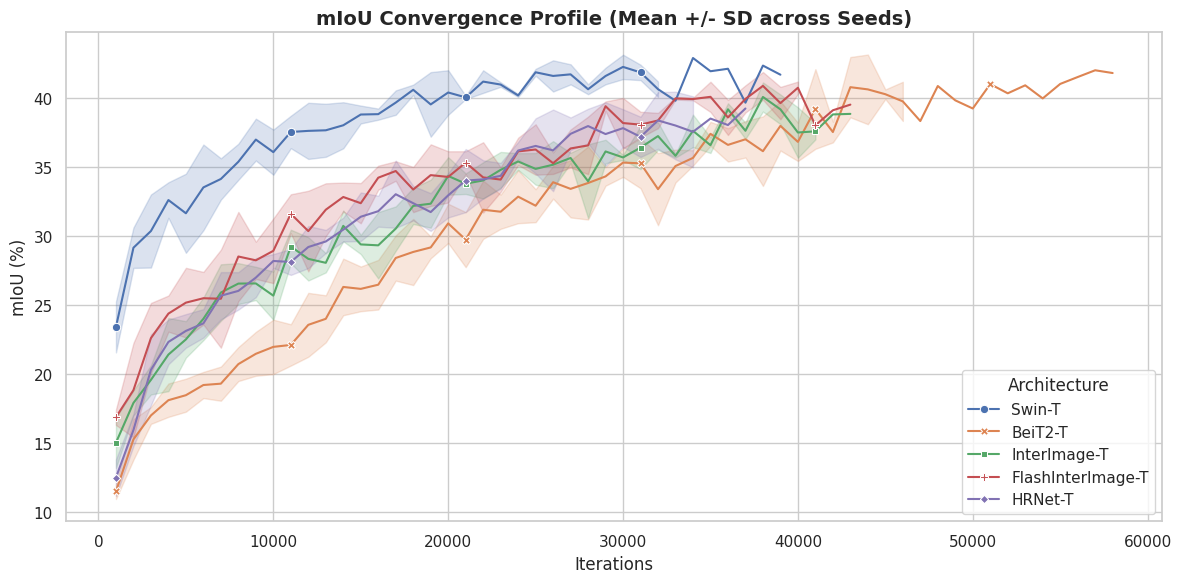

In [9]:
# mIoU convergence profile (mean +/- SD across seeds)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_master, x="iter", y="mIoU", hue="backbone", style="backbone",
             markers=True, dashes=False, markevery=10, errorbar="sd")
plt.title("mIoU Convergence Profile (Mean +/- SD across Seeds)", fontsize=14, fontweight='bold')
plt.xlabel("Iterations", fontsize=12); plt.ylabel("mIoU (%)", fontsize=12)
plt.legend(title="Architecture", loc="lower right")
plt.tight_layout(); plt.show()

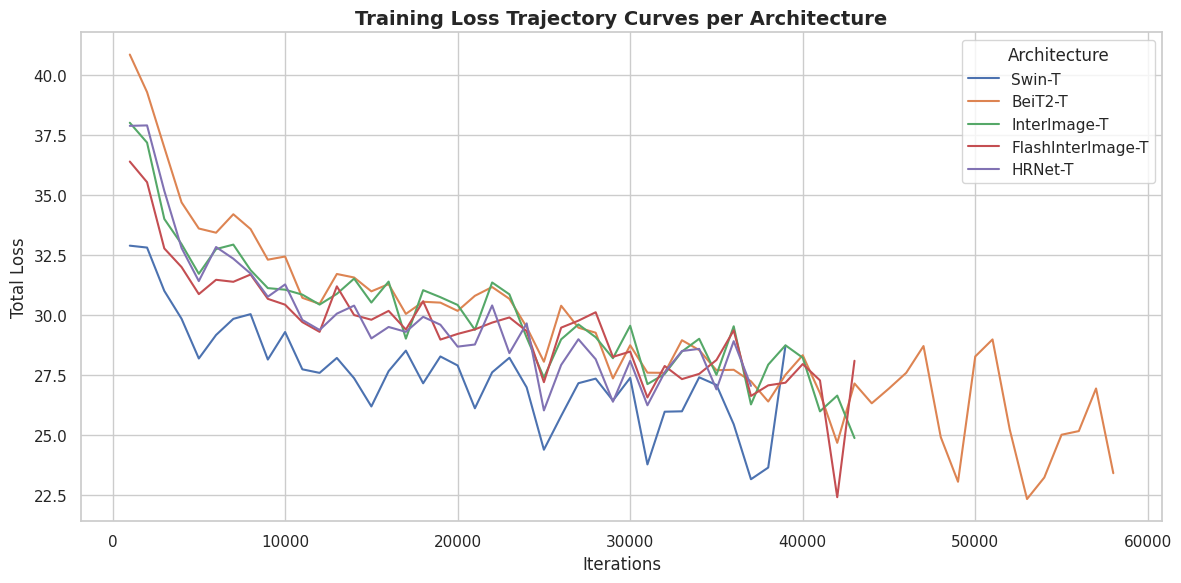

In [10]:
# Training loss trajectory
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_master, x="iter", y="loss", hue="backbone", errorbar=None)
plt.title("Training Loss Trajectory Curves per Architecture", fontsize=14, fontweight='bold')
plt.xlabel("Iterations", fontsize=12); plt.ylabel("Total Loss", fontsize=12)
plt.legend(title="Architecture", loc="upper right")
plt.tight_layout(); plt.show()

In [11]:
# Computational footprint to peak
df_compute = df_best_per_seed.groupby('backbone').agg(
    Mean_Optimal_Iter=('iter', 'mean'),
    Mean_Sec_Per_Iter=('train_time', 'mean')
).reset_index()
df_compute['Total_GPU_Hours_To_Peak'] = (df_compute['Mean_Optimal_Iter'] * df_compute['Mean_Sec_Per_Iter']) / 3600
df_compute = df_compute.sort_values(by='Total_GPU_Hours_To_Peak').reset_index(drop=True)
print(" Computational Footprint Resource Summary:")
display(df_compute.round(2))

 Computational Footprint Resource Summary:


Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


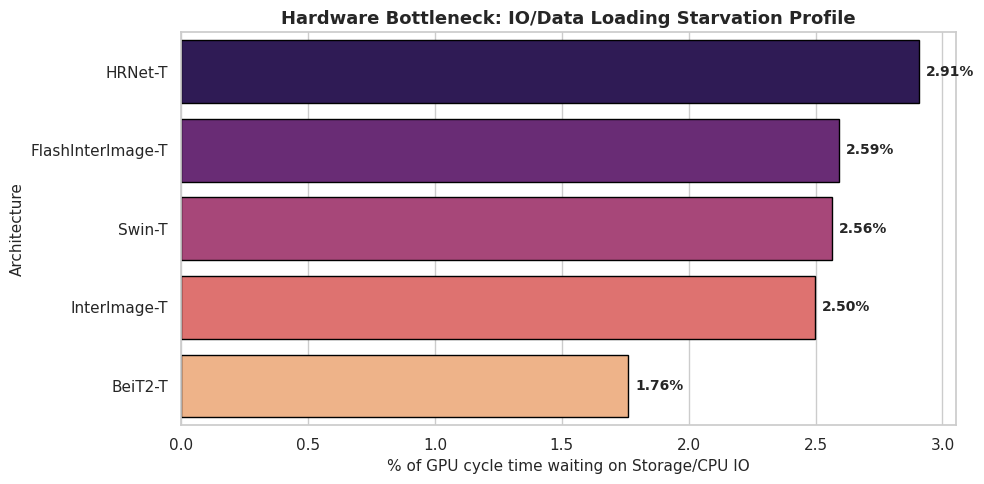

In [12]:
# Hardware bottleneck: data-loading starvation
df_hardware = df_master.groupby('backbone').agg(
    Total_Step_Time_Mean=('train_time', 'mean'),
    Data_Fetch_Time_Mean=('train_data_time', 'mean')
).reset_index()
df_hardware['Data_Loading_Bottleneck (%)'] = (df_hardware['Data_Fetch_Time_Mean'] / df_hardware['Total_Step_Time_Mean']) * 100
df_hardware = df_hardware.sort_values(by='Data_Loading_Bottleneck (%)', ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Data_Loading_Bottleneck (%)', y='backbone', data=df_hardware,
                 palette='magma', hue='backbone', legend=False, edgecolor='black')
plt.title("Hardware Bottleneck: IO/Data Loading Starvation Profile", fontsize=13, fontweight='bold')
plt.xlabel("% of GPU cycle time waiting on Storage/CPU IO", fontsize=11); plt.ylabel("Architecture", fontsize=11)
for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f}%", (p.get_width(), p.get_y() + p.get_height()/2.),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')
plt.tight_layout(); plt.show()

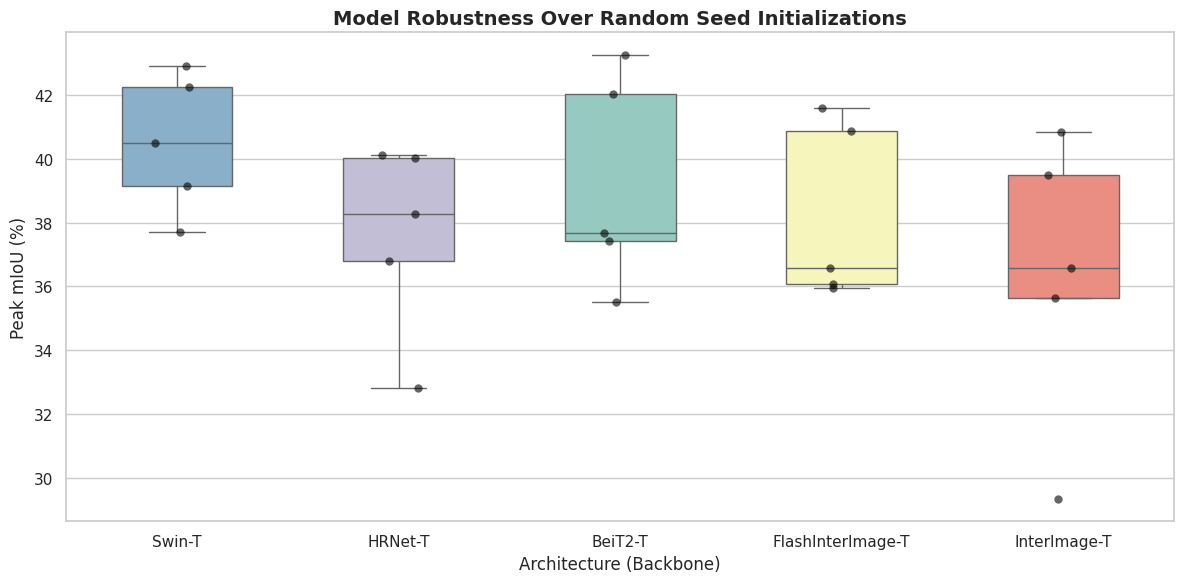

In [13]:
# Seed robustness
order_archs = df_best_per_seed.groupby('backbone')['mIoU'].median().sort_values(ascending=False).index
ax = sns.boxplot(x='backbone', y='mIoU', data=df_best_per_seed, order=order_archs,
                 palette='Set3', hue='backbone', legend=False, showfliers=False, width=0.5)
sns.stripplot(x='backbone', y='mIoU', data=df_best_per_seed, order=order_archs,
              color='black', alpha=0.6, jitter=True, size=6)
plt.title("Model Robustness Over Random Seed Initializations", fontsize=14, fontweight='bold')
plt.xlabel("Architecture (Backbone)", fontsize=12); plt.ylabel("Peak mIoU (%)", fontsize=12)
plt.tight_layout(); plt.show()

In [14]:
# Pairwise Welch's t-test on peak mIoU
import scipy.stats as stats
all_backbones = df_best_per_seed['backbone'].unique()
n_models = len(all_backbones)
rows = []
for i, a in enumerate(all_backbones):
    sa = df_best_per_seed[df_best_per_seed['backbone'] == a]['mIoU'].values
    r = []
    for j, b in enumerate(all_backbones):
        if i == j:
            r.append("-")
        else:
            sb = df_best_per_seed[df_best_per_seed['backbone'] == b]['mIoU'].values
            _, p = stats.ttest_ind(sa, sb, equal_var=False)
            r.append(f"{p:.4f}{' *' if p < 0.05 else ''}")
    rows.append(r)
df_p = pd.DataFrame(rows, index=all_backbones, columns=all_backbones)
print(" Full Pairwise p-Value Matrix (Welch's t-test):  * = p < 0.05")
display(df_p)

 Full Pairwise p-Value Matrix (Welch's t-test):  * = p < 0.05


Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)
